# 01 · Select the right model

Before you build an agent, you pick its engine — the **model**. But "best model" is the wrong question. The right question is: *best for **this** task, at what **cost**, **latency**, and **quality**?* A frontier model is amazing and expensive; a mini model is fast and cheap. Great engineers **right-size**.

In this notebook you'll run the *same* task across different models and read the trade-offs straight from the metrics — the exact intuition you'll use in lab 02 when you choose TrailMate's model.

### Learning objectives
By the end of this notebook you'll be able to:
- **Compare** a frontier model (`gpt-5.4`) with a mini model (`gpt-5.4-mini`) on cost and latency.
- **Tune** the **reasoning-effort** lever and see its price.
- **Use** multimodal understanding: have `gpt-5.4` *see* an image and describe it.
- **Chain** models — image understanding (`gpt-5.4`) → image generation (`MAI-Image-2.5-Pro`).
- **Explain** how **Model Router** picks a model per request (the lever you'll pull in lab 02).

> ⏱️ **~30 minutes** · Want to go deeper? The optional `labs/more/` notebooks expand each topic here.


## 1 · Set up and a helper to compare runs

We reuse the same `.env` you validated in notebook 00 — no new setup. Then we define one small helper, `ask(...)`, that sends a prompt and returns not just the answer but the **signals that matter for selection**: latency, token count, and which model actually served the request (important once a router is involved).


In [1]:
import os
import time
from pathlib import Path

from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient


def find_env_file() -> Path:
    """Locate the shared agent-builder/src/.env from anywhere in the tree."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        c = base / "foundry" / "agent-builder" / "src" / ".env"
        if c.exists():
            return c
        if base.name == "agent-builder" and (base / "src" / ".env").exists():
            return base / "src" / ".env"
    raise FileNotFoundError("Run 00-validate-setup first — src/.env not found.")


load_dotenv(find_env_file())
project_client = AIProjectClient(
    endpoint=os.environ["FOUNDRY_PROJECT_ENDPOINT"],
    credential=DefaultAzureCredential(),
)
openai_client = project_client.get_openai_client()


def ask(model: str, prompt: str, **kwargs) -> dict:
    """Send one chat prompt and capture the answer plus cost/latency signals."""
    start = time.perf_counter()
    
    # Chat Completions API: we're talking DIRECTLY to a model deployment — just a
    # prompt in, a completion out. No instructions, tools, or memory yet. In lab
    # 02 we wrap a model with those to make an *agent* and call it instead.
    resp = openai_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        **kwargs,
    )
    elapsed = time.perf_counter() - start
    return {
        "asked_model": model,
        "served_model": resp.model,   # a router may serve a different model
        "latency_s": round(elapsed, 2),
        "total_tokens": getattr(resp.usage, "total_tokens", None),
        "answer": resp.choices[0].message.content,
    }


print("Ready. `ask(model, prompt)` returns latency, tokens, and the answer.")


Ready. `ask(model, prompt)` returns latency, tokens, and the answer.


## 2 · Capability & cost — frontier vs mini

Same product-launch task, two engines: `gpt-5.4` (frontier) and `gpt-5.4-mini`. The table below reports, for each run:

- **`asked_model`** — the deployment you *called*.
- **`served_model`** — the model that *actually answered*. For a direct model these match; for a **router** (section 5) they can differ.
- **`latency_s`** and **`total_tokens`** — the two numbers that drive speed and cost at scale.
- **`answer_preview`** — the first line of the response, so you can judge quality against cost.

> ❓ **Your call:** For a well-specified, structured task like this JSON spec sheet, does the frontier model earn its extra tokens and latency — or is the mini model good enough? Run the cell and read the table.


In [2]:
import pandas as pd

LAUNCH_TASK = (
    "You're helping launch Contoso Outdoors gear. From the description below, "
    "return a compact JSON object with keys: name, category, key_features (list), "
    "best_for.\n\n"
    "Description: The Alpine Explorer Tent sleeps 8, has a 3000mm rainfly, taped "
    "seams, and a vestibule for storing gear."
)

# Same task, two engines.
runs = [ask("gpt-5.4", LAUNCH_TASK), ask("gpt-5.4-mini", LAUNCH_TASK)]

# One table — read the trade-off across the rows (answer quality vs tokens/latency).
df = pd.DataFrame(runs)
df["answer_preview"] = df["answer"].str.replace("\n", " ").str.slice(0, 90) + "…"
df[["asked_model", "served_model", "latency_s", "total_tokens", "answer_preview"]]


,asked_model,served_model,latency_s,total_tokens,answer_preview
0,gpt-5.4,gpt-5.4-2026-03-05,2.87,121,"{""name"":""Alpine Explorer Tent"",""category"":""ten..."
1,gpt-5.4-mini,gpt-5.4-mini-2026-03-17,0.94,122,"{""name"":""Alpine Explorer Tent"",""category"":""ten..."


## 3 · The reasoning-effort lever

Reasoning models can **think harder** when a task needs it — at the cost of more tokens and time. The `reasoning_effort` setting (`low` → `high`) is a dial you control. We give `gpt-5.4` an open-ended planning question at both settings and put the results in one table.

> ❓ **Your call:** Compare the `low` and `high` rows. Did the extra tokens at `high` effort produce a genuinely *better* plan (check `answer_preview`), or just a longer one? When is deeper reasoning worth paying for?


In [3]:
REASONING_TASK = (
    "A family of four wants ONE tent for summer car-camping with occasional light "
    "rain. Reason step by step about which specs matter (capacity, season rating, "
    "rainfly, weight) and what to look for. Be thorough."
)

effort_runs = []
for effort in ["low", "high"]:
    try:
        # reasoning_effort trades tokens/latency for deeper thinking.
        effort_runs.append({"effort": effort, **ask("gpt-5.4", REASONING_TASK, reasoning_effort=effort)})
    except Exception as err:
        print(f"reasoning_effort='{effort}' not supported on this deployment ({err}).")

df = pd.DataFrame(effort_runs)
if not df.empty:
    df["answer_preview"] = df["answer"].str.replace("\n", " ").str.slice(0, 90) + "…"
df[["effort", "latency_s", "total_tokens", "answer_preview"]] if not df.empty else None


,effort,latency_s,total_tokens,answer_preview
0,low,31.53,2848,Here’s a practical way to think through choosi...
1,high,64.47,5771,Here’s a practical way to think it through. #...


## 4 · Multimodal chat — image understanding

`gpt-5.4` isn't limited to text — it can **see**. Here we hand it the *real* Alpine Explorer Tent catalog photo and give it two jobs: **describe** what's in the image, and **write a detailed prompt** that could recreate it with an image-generation model.

Keep an eye on that recreation prompt — in the next section we feed it to an image *generator* and compare the result with this original. This is also your first taste of **chaining models**: one model's output becomes another's input.


The real product image we'll analyze:


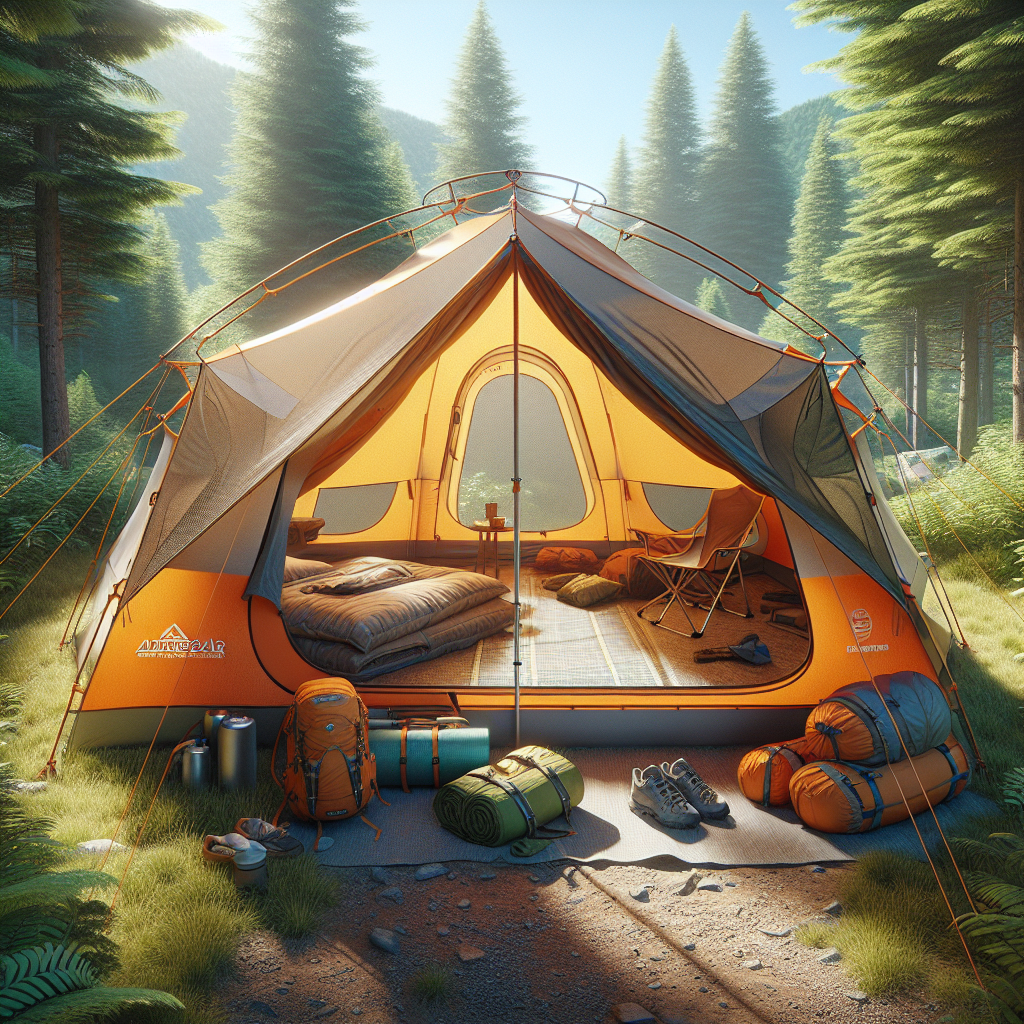


📝 Description:
 A front-facing product-style outdoor scene showing a large orange-and-gray camping tent set up in a sunny forest clearing surrounded by tall evergreen trees and distant mountain slopes. The tent doors are fully open, revealing a warm glowing interior with mesh inner doors, sleeping pads, blankets, pillows, and a folding camp chair. In front of the tent on the ground are neatly arranged camping items including an orange backpack, rolled sleeping mats, a pair of hiking shoes, metal bottles or thermoses, a mug, and bundled sleeping bags or gear sacks. The lighting is soft golden morning light, creating a cozy, inviting alpine camping atmosphere.

🎯 Recreation prompt (feeds the generator in section 5):
 Ultra-realistic product photo of a large modern alpine camping tent in a forest clearing, centered composition, straight-on front view, tent fully pitched with guy lines visible. The tent is bright orange with gray and dark mesh panels, dome/tunnel hybrid shape, and the fro

In [4]:
import base64
import json

from IPython.display import Image, display

# gpt-5.4 can SEE images (image understanding). We give it the REAL Alpine
# Explorer catalog photo and ask it to (1) describe it and (2) write a prompt to
# recreate it — that prompt becomes the input to the image GENERATOR in section 5.
AB = find_env_file().parent.parent                      # .../foundry/agent-builder
IMAGE_PATH = AB / "assets" / "products" / "alpine-explorer-tent.png"

print("The real product image we'll analyze:")
display(Image(filename=str(IMAGE_PATH)))

# Send the image inline (base64 data URL) alongside the text task.
img_b64 = base64.b64encode(IMAGE_PATH.read_bytes()).decode()
resp = openai_client.chat.completions.create(
    model="gpt-5.4",
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": (
                "This is the Alpine Explorer Tent product photo. Return ONLY a JSON "
                "object with two keys: 'description' (what the image shows) and "
                "'recreation_prompt' (a detailed text-to-image prompt that would "
                "recreate this exact image)."
            )},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
        ],
    }],
)
answer = resp.choices[0].message.content

# Pull the recreation prompt out of the JSON (fall back to raw text if needed).
try:
    parsed = json.loads(answer[answer.find("{"): answer.rfind("}") + 1])
    RECREATION_PROMPT = parsed["recreation_prompt"]
    print("\n📝 Description:\n", parsed["description"])
    print("\n🎯 Recreation prompt (feeds the generator in section 5):\n", RECREATION_PROMPT)
except Exception:
    RECREATION_PROMPT = answer
    print("\nModel output:\n", answer)


## 5 · Image generation — chaining & prompt refinement

We used `gpt-5.4` to *understand* the real photo and write a detailed recreation prompt. Now let's generate — in two steps:

1. **Hand the prompt back to `gpt-5.4`.** It's a *language* model, so it can't emit pixels — it returns **text** (typically a refined/expanded prompt), **not** an image. That's the capability boundary that makes us reach for a different model.
2. **Use `MAI-Image-2.5-Pro` twice** — once with a **naive one-line prompt**, once with the **detailed recreation prompt** `gpt-5.4` wrote — and view them **side by side**. This shows how chaining a vision model to *refine the task* produces a better image.

> 🔎 **Note:** MAI uses a **dedicated endpoint** (`/mai/v1/images/generations`), not the OpenAI chat route.

> 👀 **Observe (image "truth"):** Even the refined image won't perfectly match the real product — an *ungrounded* generator invents details. Same grounding lesson as file-search in lab 02, a problem worth solving another day.


In [5]:
# Step 1 — gpt-5.4 is a LANGUAGE model. Ask it to "generate an image" and it
# can't emit pixels: it replies with TEXT (often a refined/expanded prompt).
prompt_for_image = globals().get(
    "RECREATION_PROMPT",
    "A large 8-person tent pitched beside an alpine lake at golden hour, product-catalog style.",
)

refusal = openai_client.chat.completions.create(
    model="gpt-5.4",
    messages=[{"role": "user", "content": f"Generate an image for this prompt:\n{prompt_for_image}"}],
)
print("🗣️ gpt-5.4 was asked to GENERATE an image — it returned TEXT, not pixels:\n")
print(refusal.choices[0].message.content)


🗣️ gpt-5.4 was asked to GENERATE an image — it returned TEXT, not pixels:

Here is a concise production-ready image prompt you can use with an image model:

**Prompt:**
Ultra-realistic product photo, **1:1 square**, of a **large modern alpine camping tent** in a forest clearing, **centered composition**, **straight-on front view**, tent fully pitched with **guy lines visible**. The tent is **bright orange** with **gray and dark mesh panels**, **dome/tunnel hybrid shape**, and the **front vestibule doors pulled wide open symmetrically** to reveal the interior. Inside the tent: **warm sunlit amber glow** through the fabric, **central mesh door panel**, **two sleeping areas** with **padded mats**, **folded blankets**, **pillows**, a **woven ground mat**, and a **tan folding camp chair on the right side**. Outside the tent entrance on the ground: an **orange hiking backpack**, a **teal rolled foam sleeping pad strapped horizontally**, a **green rolled sleeping bag or mat**, a **pair of gra


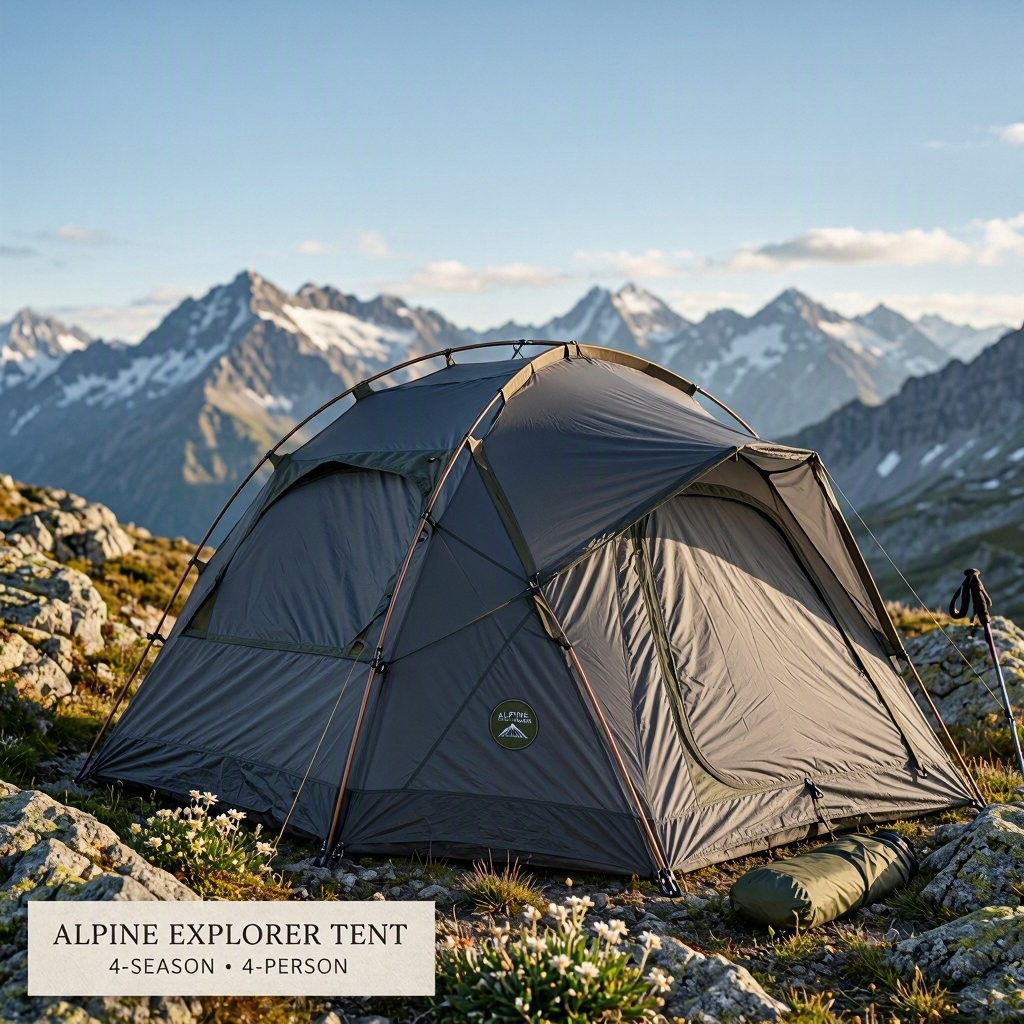
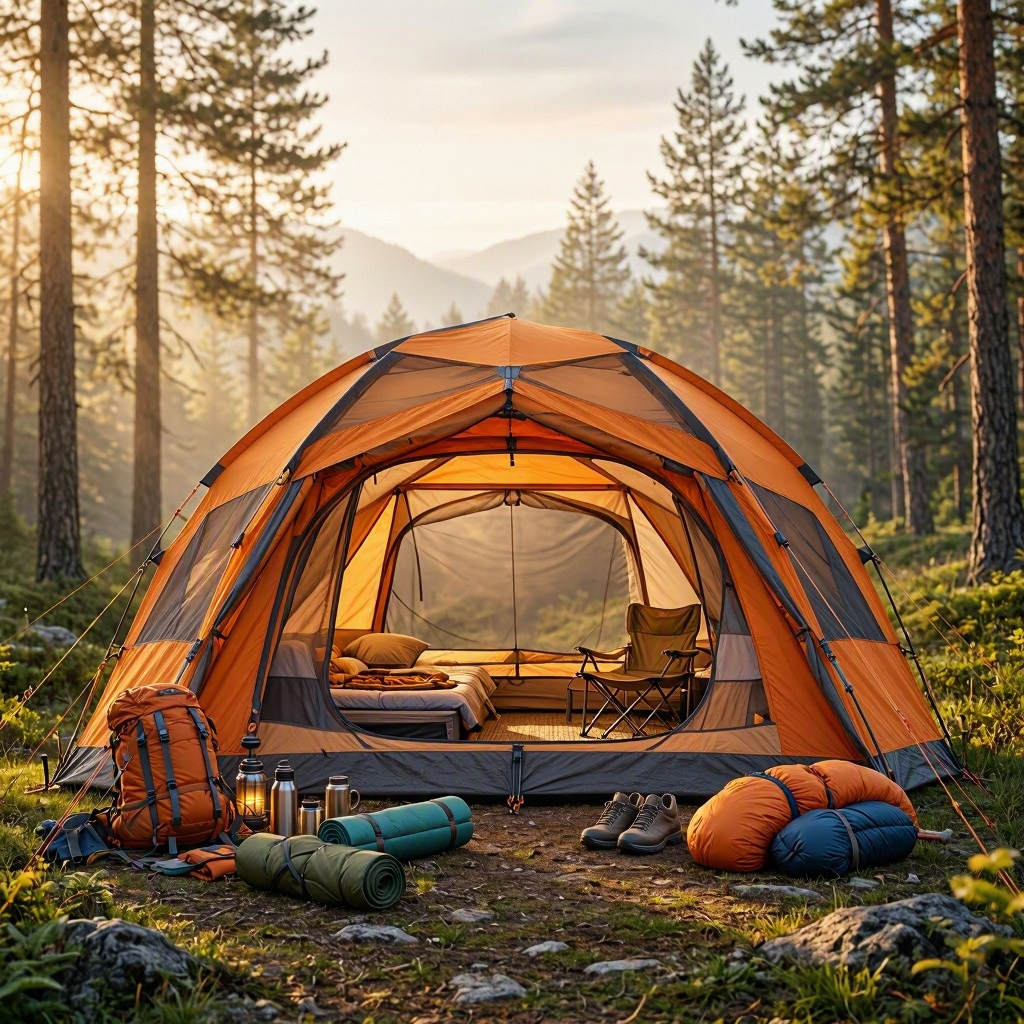

Left = naive one-liner · Right = detailed prompt chained from gpt-5.4's vision.
Chaining a vision model to refine the task gives the generator far more to work with.


In [6]:
import base64
from urllib.parse import urlparse

import requests
from azure.identity import DefaultAzureCredential
from IPython.display import HTML, display

# Step 2 — switch to MAI (a dedicated image model on its own endpoint) and run it
# TWICE: a naive one-liner vs the detailed prompt gpt-5.4 wrote from the real photo.
resource = urlparse(os.environ["FOUNDRY_PROJECT_ENDPOINT"])
mai_url = f"{resource.scheme}://{resource.netloc}/mai/v1/images/generations"
token = DefaultAzureCredential().get_token("https://cognitiveservices.azure.com/.default").token


def generate_image(prompt: str) -> str:
    """Call MAI and return the generated image as a base64 PNG string."""
    r = requests.post(
        mai_url,
        headers={"Content-Type": "application/json", "Authorization": f"Bearer {token}"},
        json={"model": "MAI-Image-2.5-Pro", "prompt": prompt, "width": 1024, "height": 1024},
        timeout=120,
    )
    r.raise_for_status()
    return r.json()["data"][0]["b64_json"]


DEFAULT_PROMPT = "A product photo of the Alpine Explorer Tent."
REFINED_PROMPT = globals().get("RECREATION_PROMPT", DEFAULT_PROMPT)

try:
    img_default = generate_image(DEFAULT_PROMPT)
    img_refined = generate_image(REFINED_PROMPT)
    display(HTML(f"""
    <div style="display:flex;gap:20px;text-align:center">
      <figure style="margin:0">
        <img src="data:image/png;base64,{img_default}" width="360"/>
        <figcaption><b>Naive prompt</b><br/><small>"{DEFAULT_PROMPT}"</small></figcaption>
      </figure>
      <figure style="margin:0">
        <img src="data:image/png;base64,{img_refined}" width="360"/>
        <figcaption><b>Refined prompt</b><br/><small>written by gpt-5.4 from the real photo</small></figcaption>
      </figure>
    </div>"""))
    print("Left = naive one-liner · Right = detailed prompt chained from gpt-5.4's vision.")
    print("Chaining a vision model to refine the task gives the generator far more to work with.")
except Exception as err:
    print(f"Image generation call failed ({err}).")
    print("You can also try MAI-Image-2.5-Pro in the Foundry portal → Images playground.")


## 6 · Let the router decide — Model Router

What if you didn't have to choose per request? **Model Router** looks at each prompt and routes it to an appropriately sized model — cheap ones for easy asks, stronger ones for hard ones. Because you call one `model-router` deployment but a *different* model may answer, this is where **`asked_model`** and **`served_model`** come apart.

> ❓ **Your call:** In the table, compare `served_model` for the **simple** vs **complex** prompt. Did the router send them to different models? Would you have picked the same way by hand? This is exactly the lever you'll pull for TrailMate v2 in lab 02.


In [7]:
SIMPLE = "In one sentence, what is the capital of France?"
COMPLEX = (
    "Plan a 3-day, 2-night backpacking trip for two in the Cascades in early "
    "autumn. Consider weather, gear, food, and safety, and lay out a day-by-day "
    "plan with your reasoning."
)

router_runs = []
for label, prompt in [("simple", SIMPLE), ("complex", COMPLEX)]:
    r = ask("model-router", prompt)
    r["ask"] = label
    router_runs.append(r)

# One table — did asked (model-router) and served (the chosen model) diverge?
pd.DataFrame(router_runs)[["ask", "asked_model", "served_model", "latency_s", "total_tokens"]]


,ask,asked_model,served_model,latency_s,total_tokens
0,simple,model-router,gpt-5-mini-2025-08-07,1.50,33
1,complex,model-router,grok-4-1-fast-reasoning,21.45,3868


## 🧭 Summary — so, how do I pick a model?

You just built the core intuition for model selection:

| Signal | What you saw | Why it matters |
|---|---|---|
| **Capability** | frontier vs mini on the same task | Only pay for capability the task needs |
| **Cost** | token counts side by side | Tokens ≈ money at scale |
| **Latency** | seconds per call | User experience and throughput |
| **Reasoning effort** | `low` vs `high` token cost | Spend "thinking" only where it changes the answer |
| **Multimodal** | `gpt-5.4` *sees* and describes an image | Some tasks need vision, not just text |
| **Chaining** | vision prompt → `MAI-Image-2.5-Pro` | Combine specialized models; each does what it's best at |
| **Model Router** | one endpoint, different served models | Right-size *per request*, automatically |

**Two takeaways:**
1. There's no single "best" model — there's the best model *for this task, cost, and latency*. Model Router lets you defer that choice to runtime (TrailMate's first optimization lever).
2. **Grounding matters for images too.** The generated tent didn't match the real product — an *ungrounded* image. Just like text answers need file-search grounding (lab 02), images need grounding to reflect reality.

### Next
➡️ Open **[02 · Build, evaluate & optimize the agent](02-agent-optimization.ipynb)** — where you'll build TrailMate, measure a baseline, and hill-climb with Model Router and Agent Optimizer.
